# Piplie For Reachability Analysis of Duffing Oscillator (Nonlienar) Under A Fix Contorl Law

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from scipy.linalg import solve_discrete_are
from pykoopman import observables, regression
import pykoopman as pk
from KRTB_pyKoopman import KoopmanModelTrainer, KoopmanAnalysis, integralRK4
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

**Load configs and define the system**

In [2]:
np.random.seed(5)

curdir = os.path.dirname("duffing_KRTB_FixedController.ipynb")
config_path = os.path.join(curdir, "configs", "controlled_duffing.json")
stream = print

kmt = KoopmanModelTrainer(config_path, curdir, save_model=True, save_sim_data=True, stream=stream)

## Phase A: Learn system dynamic with open-loop data

In [3]:
def genRandControlCmd(n_sample, t_vec): 
    amp = np.random.uniform(-1, 1, size=n_sample) 
    f = 0.5 # signal frequency (Hz) 
    U = np.outer(amp, (np.sin(2 * np.pi * f * t_vec) >= 0)) 
    return np.expand_dims(U, axis=2)

**Generate open-loop simulated trajectories**

In [4]:
states_ol, controls_ol, t_vec = kmt.simTrajOpenLoop(genRandControlCmd)

Simulating trajectories ...
Simulation is Done!
Generating Simulated Trajectory to Train a Koopman Model
 Num. simulated trajectories: 5000
 Random seed: None
 State bounds: 
  x1: [-2, 2]
  x2: [-2, 2]

 Simulation time span (sec): 5.000 [0.000, 5.000] 
 Time step(sec): 0.01 
 Process runtime (sec): 0.664
 Simulated trajectories are stored at: sim_trajectories/duffing.npz


#### Plot Random open-loop simulated trajectories for demonstration

[-1.67703492 -1.09172759]


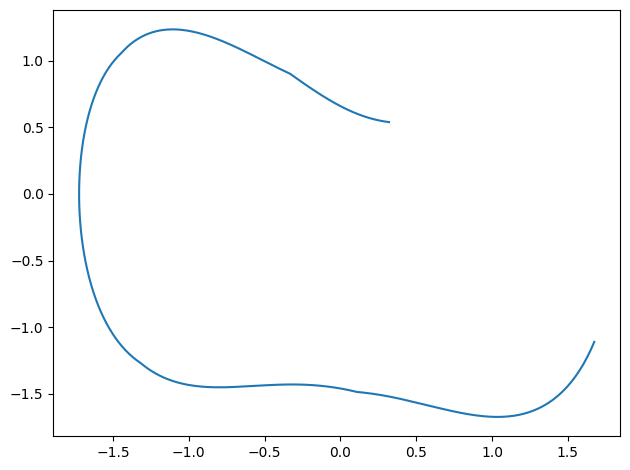

In [23]:
# rand_num = np.random.randint(0, 5000, 5)
rand_num = [3]
fig, ax = plt.subplots()
for i in rand_num:
    ax.plot(states_ol[i, :, 0], states_ol[i, :, 1])
print(states_ol[10, 0, :])

plt.tight_layout()
plt.show()

### Train open-loop EDMD with Control

**Define dectionary of observables**

In [5]:
centers = np.random.uniform(-1.5, 1.5, (2, 15))   # 20 centers
obs = observables.RadialBasisFunction(
    rbf_type="thinplate",
    n_centers=centers.shape[1],
    centers=centers,
    kernel_width=1.0,
    polyharmonic_coeff=1.0,
    include_state=True,
)

**Fit EDMDc**

In [6]:
reg = regression.EDMDc()
pk_edmdc = kmt.trainPyKoopmanModel(states_ol, controls=controls_ol, regressor=reg, observables=obs)

Training a pyKoopman Model based on Simulated Trajectories

 Process runtime (sec): 6.876755
 Trained model is stored at: sim_trajectories/duffing.npz


#### EDMDc trajectory simulation for demonstration

/home/ali/my_ws/Thesis/venv/lib/python3.10/site-packages/pykoopman/koopman.py:302: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


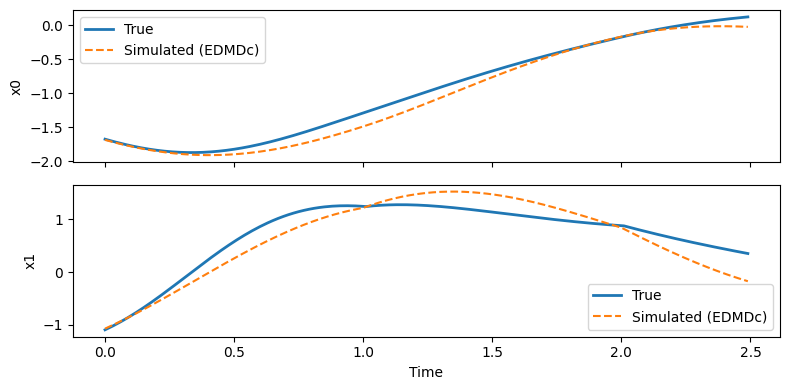

In [26]:
idx = 10
n_ss = 250

X_true = states_ol[idx, :n_ss]
traj_u = controls_ol[idx, :n_ss]
x0 = X_true[0]

X_sim = pk_edmdc.simulate(x0, traj_u, n_ss)

t = t_vec[:X_sim.shape[0]]
n_states = X_true.shape[1]
fig, axs = plt.subplots(n_states, 1, figsize=(8, 2*n_states), sharex=True)

for i in range(n_states):
    axs[i].plot(t, X_true[:, i], label="True", linewidth=2)
    axs[i].plot(t, X_sim[:, i], "--", label="Simulated (EDMDc)")
    axs[i].set_ylabel(f"x{i}")
    axs[i].legend()

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

### Desing Koopman LQR Controller on lifted linear model

\begin{align}
z_{k+1} = A z_{k} + B \pi(x_{k}), \ \ \ with \ \ \ x_k = C z_k
\end{align}

In [7]:
def dlqr(A, B, Q, R):
    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.inv(B.T @ P @ B + R) @ (B.T @ P @ A)
    return K, P

def sat(u, umax):
    return np.clip(u, -umax, umax)

def koopman_lqr_u(x, K, pk_model, umax=1.0):
    x1e = -2.0
    x_eq = np.array([x1e, 0.0])
    u_eq = x1e**3 - x1e   # feedforward that makes x_eq an equilibrium
    
    z = pk_model.observables.transform(x)
    z_ref = pk_model.observables.transform(x_eq.reshape(1, -1))
    v = -K @ (z - z_ref).T  # feedback term
    u = v + u_eq # total = feedforward + feedback
    # return sat(u, umax).reshape(1, -1)
    return u

In [8]:
A = pk_edmdc.A
B = pk_edmdc.B
C = pk_edmdc.C
nz = A.shape[0]

Qx = np.diag([1, 10])
Q = C.T @ Qx @ C + 1e-6*np.eye(nz)
R = np.array([[3]]) # tune this

K, _ = dlqr(A, B, Q, R)

## Phase B: Learn closed-loop dynamic underf fixed policy $ u_k=\pi(x_k)\ $

#### How does the close-loop dynamic looks like with this policy?

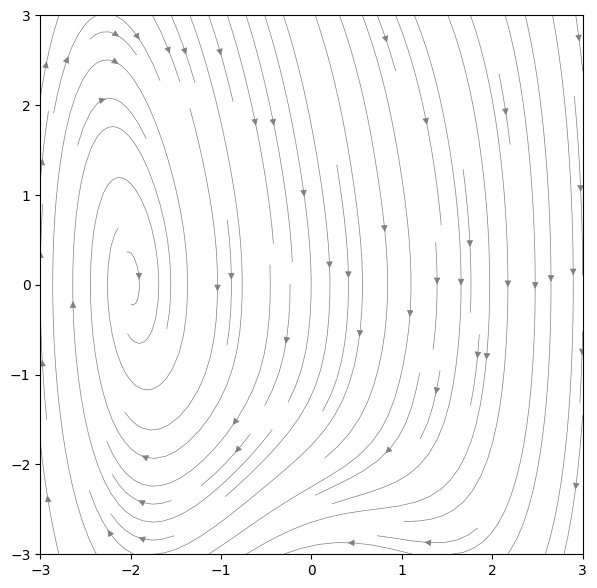

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
x_lim = [-3, 3]
y_lim = [-3, 3]

grid_x = np.linspace(x_lim[0], x_lim[1], 30)
grid_y = np.linspace(y_lim[0], y_lim[1], 30)
X, Y = np.meshgrid(grid_x, grid_y)
points = np.stack([X.ravel(), Y.ravel()], axis=-1)

vecs = np.array([kmt.system.ff(pt.reshape(1, -1), koopman_lqr_u(pt.reshape(1, -1), K, pk_edmdc)) for pt in points])

U = vecs[:, 0].reshape(X.shape)
V = vecs[:, 1].reshape(X.shape)
ax.streamplot(X, Y, U, V, color="gray", density=1.0, linewidth=0.5, arrowsize=1)

plt.show()

### Simulated closed-loop trajectories

In [9]:
states_cl, controls_cl, t_vec =  kmt.simTrajClosedLoop(koopman_lqr_u, K=K, pk_model=pk_edmdc)

Simulating trajectories ...
Simulation is Done!
Generating Simulated Trajectory to Train a Koopman Model
 Num. simulated trajectories: 5000
 Random seed: None
 State bounds: 
  x1: [-2, 2]
  x2: [-2, 2]

 Simulation time span (sec): 5.000 [0.000, 5.000] 
 Time step(sec): 0.01 
 Process runtime (sec): 6.066
 Simulated trajectories are stored at: sim_trajectories/duffing.npz


### Train close-loop EDMD (now the control law is fused inside the system dynamic)

In [13]:
centers = np.random.uniform(-1.5, 1.5, (2, 15))   # 20 centers
# obs2 = observables.RadialBasisFunction(
#     rbf_type="thinplate",
#     n_centers=centers.shape[1],
#     centers=centers,
#     kernel_width=1.0,
#     polyharmonic_coeff=1.0,
#     include_state=True,
# )

obs2 = observables.Polynomial(degree=5)

reg = regression.EDMD()
pk_edmd = kmt.trainPyKoopmanModel(states_cl, regressor=reg, observables=obs2)

Training a pyKoopman Model based on Simulated Trajectories

 Process runtime (sec): 7.104644
 Trained model is stored at: sim_trajectories/duffing.npz


#### EDMD trajectory simulation for demonstration

/home/ali/my_ws/Thesis/venv/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


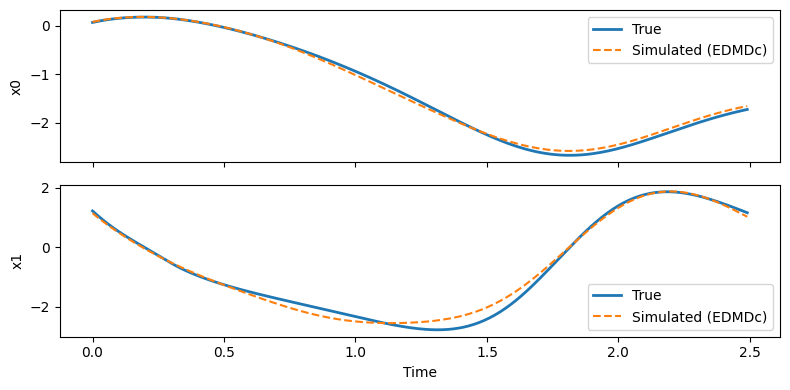

In [14]:
idx = 10
n_ss = 250

X_true = states_cl[idx, :n_ss]
x0 = X_true[0]

X_sim = pk_edmd.simulate(x0, n_steps=n_ss)

t = t_vec[:X_sim.shape[0]]
n_states = X_true.shape[1]
fig, axs = plt.subplots(n_states, 1, figsize=(8, 2*n_states), sharex=True)

for i in range(n_states):
    axs[i].plot(t, X_true[:, i], label="True", linewidth=2)
    axs[i].plot(t, X_sim[:, i], "--", label="Simulated (EDMDc)")
    axs[i].set_ylabel(f"x{i}")
    axs[i].legend()

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Phase C: Reachability analysis on closed-loop dynamic

**Identify more accurate eigenfunctions**

In [15]:
kAnalysis = KoopmanAnalysis(config_path, pk_edmd, stream=stream)
kAnalysis.listEigVal()
_, valid_idx = kAnalysis.eigFunValidity(states_cl, t_vec, alpha=1, score_threshold=2)

Continuous Eigenvales

 eig_v 0 = -1.030+11.629j
 eig_v 1 = -1.030-11.629j
 eig_v 2 = -0.941+8.589j
 eig_v 3 = -0.941-8.589j
 eig_v 4 = -3.672+6.617j
 eig_v 5 = -3.672-6.617j
 eig_v 6 = -1.003+6.015j
 eig_v 7 = -1.003-6.015j
 eig_v 8 = -1.066+4.890j
 eig_v 9 = -1.066-4.890j
 eig_v 10 = -4.064+1.467j
 eig_v 11 = -4.064-1.467j
 eig_v 12 = -0.423+2.978j
 eig_v 13 = -0.423-2.978j
 eig_v 14 = -1.024+2.374j
 eig_v 15 = -1.024-2.374j
 eig_v 16 = 0.000+0.000j
 eig_v 17 = -1.359+0.174j
 eig_v 18 = -1.359-0.174j
 eig_v 19 = -2.001+1.989j
 eig_v 20 = -2.001-1.989j
Pykoopman Validity Check

Eigenfunction scores based on linearity and invariant error:
[5.49070693e+01 5.49070693e+01 4.73668254e+01 4.73668254e+01
 2.20800524e+01 2.20800524e+01 3.17292142e+01 3.17292142e+01
 2.59787292e+01 2.59787292e+01 2.11376122e+01 2.11376122e+01
 6.14536093e+00 6.14536093e+00 1.48645048e+01 1.48645048e+01
 1.95409457e-10 1.13548200e+01 1.13548200e+01 2.34214450e+01
 2.34214450e+01]

Eigenfunction ranking (best to

**Run time to reach bound algorithm**

In [18]:
inital_set = [{
    "type": "box",
    "bounds": [[1.68, 1.88],[1.16, 1.36]]
}]
target_set = [{
    "type": "box",
    "bounds": [[-2.2, -1.9],[-0.3, -0.1]]
}]

kAnalysis.timeReachBound(
    valid_ef_idx=np.array([12, 13]), 
    n_samples=1000, 
    initial_sets=inital_set, 
    target_sets=target_set
)

Reach-Time bound Analysis

Status: ('PROBABLY REACHABLE', 3)
Reach-time bounds (time intervals when trajectory is in target set):
  Interval 1: [5.487901, 6.468769]
  Interval 2: [7.597902, 8.578771]
  Interval 3: [9.707904, 10.688772]

Process time: 0.119102


([(5.487900878518436, 6.4687694408287015),
  (7.597902289996882, 8.578770852307148),
  (9.707903701475328, 10.688772263785593)],
 ('PROBABLY REACHABLE', 3))

**Varify the reachability with simulation**

Result of reachability with simulation

All trajectories reach the target set with in time bound [6.010, 6.040]
 Process runtime (sec): 0.465923


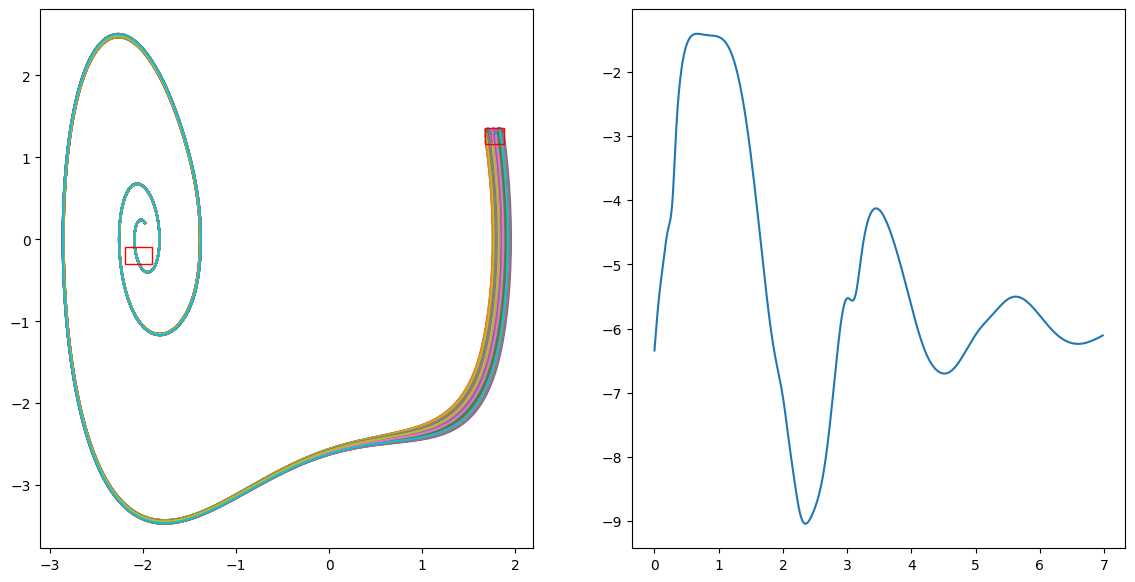

In [21]:
T = 7
dt = 0.01
tested_traj, U = kAnalysis.verifyReachabilityWithSim_c(
    controller=koopman_lqr_u,
    n_samples=100, 
    final_time=T, 
    deltaT=dt,
    initial_set=inital_set,
    target_set=target_set,
    pk_model=pk_edmdc,
    K=K
)


fig, ax = plt.subplots(1, 2, figsize=(14, 7))
a = 0.2
rect1 = patches.Rectangle((1.68, 1.16), a, a, edgecolor='r', facecolor='none', zorder=3)
rect2 = patches.Rectangle((-2.2, -0.3), 0.3, a, edgecolor='r', facecolor='none', zorder=3)
ax[0].add_patch(rect1)
ax[0].add_patch(rect2)

for traj in tested_traj:
    ax[0].plot(traj[:, 0], traj[:, 1])

ax[1].plot(np.arange(0, T-dt, dt), U[0,:-1].squeeze())

plt.show()

#### Pipeline

In [ ]:
import numpy as np
from numpy.random import default_rng
from scipy.linalg import solve_discrete_are
import pykoopman as pk


# ---------------------------
# 1) Duffing discrete-time simulator (Euler; replace with RK4 if you want)
# ---------------------------
def duffing_step(x, u, dt, d=0.02, alpha=-1.0, beta=1.0):
    """
    Duffing: x1' = x2
             x2' = -d*x2 - alpha*x1 - beta*x1^3 + u
    Note: some conventions differ; adjust signs to match your model_fd.
    """
    x1, x2 = x[..., 0], x[..., 1]
    x1dot = x2
    x2dot = -d * x2 - alpha * x1 - beta * (x1**3) + u.squeeze(-1)
    x_next = np.stack([x1 + dt * x1dot, x2 + dt * x2dot], axis=-1)
    return x_next


def rollout_open_loop(x0, U, dt, **duff_params):
    """
    Rollout with provided input sequence U (T, 1).
    Returns X (T,2), Y (T,2), U_used (T,1)
    """
    T = U.shape[0]
    x = x0.copy()
    X = np.zeros((T, 2))
    Y = np.zeros((T, 2))
    for k in range(T):
        X[k] = x
        x = duffing_step(x[None, :], U[k:k+1], dt, **duff_params)[0]
        Y[k] = x
    return X, Y, U


# ---------------------------
# 2) EDMDc fit (open-loop)
# ---------------------------
def fit_edmdc_open_loop(X, Y, U, observables):
    """
    X,Y shape: (N,2), U shape: (N,1)
    """
    reg = pk.regression.EDMDc()
    model = pk.Koopman(observables=observables, regressor=reg)
    model.fit(X, y=Y, u=U)
    return model


# ---------------------------
# 3) Koopman LQR design on lifted linear model
# ---------------------------
def dlqr(A, B, Q, R):
    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.inv(B.T @ P @ B + R) @ (B.T @ P @ A)
    return K, P


def sat(u, umax):
    return np.clip(u, -umax, umax)


def koopman_lqr_u(x, x_ref, pk_model, K, umax=1.0):
    """
    x: (n,2) batch, x_ref: (2,)
    """
    # Lift
    z = pk_model.observables.transform(x)                    # (n, nz)
    z_ref = pk_model.observables.transform(x_ref.reshape(1, -1))  # (1, nz)

    # LQR policy in lifted coordinates
    u = - (K @ (z - z_ref).T)                                # (1, n)
    u = u.T                                                  # (n, 1)
    return sat(u, umax)


# ---------------------------
# 4) Closed-loop data collection using fixed policy u = pi(x)
# ---------------------------
def rollout_closed_loop(x0, dt, pk_model, K, x_ref, T, umax=1.0, **duff_params):
    """
    Closed-loop rollout: u_k = pi(x_k) (fixed controller), then propagate true Duffing.
    Returns X (T,2), Y (T,2) and U_used (T,1).
    """
    x = x0.copy()
    X = np.zeros((T, 2))
    Y = np.zeros((T, 2))
    U_used = np.zeros((T, 1))

    for k in range(T):
        X[k] = x
        u = koopman_lqr_u(x.reshape(1, -1), x_ref, pk_model, K, umax=umax)  # (1,1)
        U_used[k] = u[0]
        x = duffing_step(x[None, :], u[None, :], dt, **duff_params)[0]
        Y[k] = x

    return X, Y, U_used


# ---------------------------
# 5) Fit an autonomous Koopman model on closed-loop data (EDMD)
#    This makes your timeReachBound() logic valid again.
# ---------------------------
def fit_edmd_closed_loop(X, Y, observables):
    reg = pk.regression.EDMD()
    model = pk.Koopman(observables=observables, regressor=reg)
    model.fit(X, y=Y)
    return model


# ---------------------------
# 6) Example main script tying everything together
# ---------------------------
if __name__ == "__main__":
    rng = default_rng(0)

    dt = 0.01
    duff_params = dict(d=0.02, alpha=-1.0, beta=1.0)

    # ---- Choose observables (same as your RBF example) ----
    centers = rng.uniform(-1.5, 1.5, (2, 20))   # 20 centers
    obs = pk.observables.RadialBasisFunction(
        rbf_type="thinplate",
        n_centers=centers.shape[1],
        centers=centers,
        kernel_width=1.0,
        polyharmonic_coeff=1.0,
        include_state=True,
    )

    # ======================================================
    # Phase A: Open-loop data -> EDMDc -> (A,B,C)
    # ======================================================
    N_open = 5000
    x0 = rng.uniform(-1, 1, size=(2,))
    U_open = rng.uniform(-1, 1, size=(N_open, 1))  # open-loop excitation

    Xo, Yo, Uo = rollout_open_loop(x0, U_open, dt, **duff_params)

    pk_edmdc = fit_edmdc_open_loop(Xo, Yo, Uo, obs)

    A = pk_edmdc.A
    B = pk_edmdc.B
    C = pk_edmdc.C  # mapping from lifted state to original state (if available)

    nz = A.shape[0]

    # ---- Define LQR weights in lifted coords ----
    Qx = np.diag([10.0, 1.0])
    Q = C.T @ Qx @ C + 1e-6*np.eye(nz)
    R = np.array([[0.01]])

    K, _ = dlqr(A, B, Q, R)

    # ======================================================
    # Phase B: Closed-loop rollouts under fixed policy u=pi(x)
    #         then fit autonomous EDMD model for reachability
    # ======================================================
    x_ref = np.array([2.0, 0.0])
    umax = 1.0

    # Collect multiple closed-loop trajectories from different initial conditions
    n_traj = 50
    T_cl = 2000

    Xcl_list, Ycl_list = [], []
    for _ in range(n_traj):
        x0 = rng.uniform(-1, 1, size=(2,))
        Xcl, Ycl, Ucl = rollout_closed_loop(
            x0, dt, pk_edmdc, K, x_ref, T_cl, umax=umax, **duff_params
        )
        Xcl_list.append(Xcl)
        Ycl_list.append(Ycl)

    Xcl_all = np.vstack(Xcl_list)  # (n_traj*T_cl,2)
    Ycl_all = np.vstack(Ycl_list)

    # Fit autonomous Koopman model for the closed-loop system:
    pk_cl = fit_edmd_closed_loop(Xcl_all, Ycl_all, obs)

    print("Open-loop EDMDc learned:", pk_edmdc.A.shape, pk_edmdc.B.shape)
    print("Closed-loop EDMD learned:", pk_cl.A.shape)

    # Now use pk_cl inside your timeReachBound(), because it is autonomous.